In [ ]:
pip install librosa soundfile gradio scikit-learn matplotlib seaborn

In [ ]:
!pip install resampy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 82.3 MB/s eta 0:00:00


In [ ]:
import os
import urllib.request
import zipfile

# 1. Create a directory for the dataset
os.makedirs('./ravdess_data', exist_ok=True)

# 2. URL of the RAVDESS Speech Dataset (Kaggle mirror link)
url = "https://zenodo.org/record/1188976/files/Audio_Speech_Actors_01-24.zip?download=1"
zip_path = "./ravdess_data/audio.zip"

print("Downloading dataset (This might take 1-2 minutes)...")
urllib.request.urlretrieve(url, zip_path)

# 3. Extracting the zip file
print("Extracting files...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('./ravdess_data/')

print("Dataset is ready!")

Extracting files...
Dataset is ready!


In [ ]:
import glob
import os
import librosa
import numpy as np

emotions_map = {
    '01': 'neutral',
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'fearful'
}

def extract_all_features(file_path):
    X, sample_rate = librosa.load(file_path, res_type='kaiser_fast')

    # 1. MFCCs (40 coefficients)
    mfccs = librosa.feature.mfcc(y=X, sr=sample_rate, n_mfcc=40)
    mfccs_scaled = np.mean(mfccs.T, axis=0)

    # 2. Pitch (using Harmonic-to-Noise Ratio or PiPT to represent Pitch contour)
    pitches, magnitudes = librosa.piptrack(y=X, sr=sample_rate)
    pitch_mean = np.mean(pitches[magnitudes > np.max(magnitudes)*0.1]) if np.max(magnitudes) > 0 else 0
    if np.isnan(pitch_mean): pitch_mean = 0

    # 3. Energy (Root Mean Square - RMS Energy)
    rms_energy = librosa.feature.rms(y=X)
    energy_scaled = np.mean(rms_energy.T, axis=0)

    # 4. Frequency Variation (Zero Crossing Rate & Spectral Centroid)
    zcr = librosa.feature.zero_crossing_rate(y=X)
    zcr_scaled = np.mean(zcr.T, axis=0)

    spec_centroid = librosa.feature.spectral_centroid(y=X, sr=sample_rate)
    centroid_scaled = np.mean(spec_centroid.T, axis=0)

    # Combined Feature Vector: [MFCCs (40) + Pitch (1) + Energy (1) + Freq_Var_1 (1) + Freq_Var_2 (1)]
    # Total features per audio = 44
    combined_features = np.hstack((mfccs_scaled, pitch_mean, energy_scaled, zcr_scaled, centroid_scaled))
    return combined_features

data_X = []
data_y = []

file_pattern = "./ravdess_data/Actor_*/*.wav"
all_files = glob.glob(file_pattern, recursive=True)

print(f"Processing {len(all_files)} audio files with all 4 required features...")

for file in all_files:
    filename = os.path.basename(file)
    part = filename.split('-')
    if len(part) >= 3:
        emotion_code = part[2]
        if emotion_code in emotions_map:
            features = extract_all_features(file)
            data_X.append(features)
            data_y.append(emotions_map[emotion_code])

X = np.array(data_X)
y = np.array(data_y)

print(f"Extraction Done! Total valid samples processed : {X.shape[0]}")
print(f"Data shape per audio file: {X.shape}")
# Output vector shape input should be (samples, 44)

Processing 1440 audio files with all 4 required features...
Extraction Done! Total valid samples processed : 864
Data shape per audio file: (864, 44)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

if len(y) == 0:
    print("Error: Your array is still empty. Check if zip extracted properly!")
else:

    le = LabelEncoder()
    y_encoded = le.fit_transform(y)
    y_categorical = to_categorical(y_encoded)

    X_train, X_test, y_train, y_test = train_test_split(X, y_categorical, test_size=0.2, random_state=42)

    # Reshaping with new feature length (44)
    X_train = np.expand_dims(X_train, axis=-1)
    X_test = np.expand_dims(X_test, axis=-1)

    print(f"Train set size: {X_train.shape}, Test set size: {X_test.shape}")

Train set size: (691, 44, 1), Test set size: (173, 44, 1)


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, Flatten, Dropout, MaxPooling1D, BatchNormalization

# Optimized CNN Architecture with Batch Normalization
model_opt = Sequential([
    Conv1D(256, kernel_size=5, strides=1, padding='same', activation='relu', input_shape=(X_train.shape[1], 1)),
    BatchNormalization(),
    MaxPooling1D(pool_size=5, strides=2, padding='same'),

    Conv1D(128, kernel_size=5, strides=1, padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=5, strides=2, padding='same'),
    Dropout(0.2),

    Conv1D(64, kernel_size=5, strides=1, padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=5, strides=2, padding='same'),
    Dropout(0.3),

    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.4),
    Dense(len(le.classes_), activation='softmax')
])

# Using Adam with controlled learning rate for deep tracking
opt = tf.keras.optimizers.Adam(learning_rate=0.001)
model_opt.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

print("Training the Optimized Network...")
# Training for 70 epochs with class weights handling capability
history = model_opt.fit(X_train, y_train, epochs=70, batch_size=64, validation_data=(X_test, y_test))

# Re-assigning our model variable name to fit step 6 and step 7 easily
model = model_opt

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training the Optimized Network...
Epoch 1/70
11/11 ━━━━━━━━━━━━━━━━━━━━ 15s 628ms/step - accuracy: 0.2373 - loss: 2.5510 - val_accuracy: 0.2312 - val_loss: 32.4735
Epoch 2/70
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2822 - loss: 1.9461 - val_accuracy: 0.3410 - val_loss: 10.1175
Epoch 3/70
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3126 - loss: 1.7025 - val_accuracy: 0.3237 - val_loss: 3.7886
Epoch 4/70
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3025 - loss: 1.5866 - val_accuracy: 0.3410 - val_loss: 3.2797
Epoch 5/70
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3227 - loss: 1.4673 - val_accuracy: 0.2890 - val_loss: 2.1525
Epoch 6/70
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3198 - loss: 1.4770 - val_accuracy: 0.3699 - val_loss: 1.6175
Epoch 7/70
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3473 - loss: 1.4535 - val_accuracy: 0.3757 - val_loss: 1.5423
Epoch 8/70
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3285 - l

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
===================  DELIVERABLE: EVALUATION METRICS ===================
              precision    recall  f1-score   support

       angry       0.79      0.78      0.78        40
     fearful       0.45      0.92      0.60        37
       happy       0.38      0.24      0.29        42
     neutral       1.00      0.05      0.09        22
         sad       0.58      0.56      0.57        32

    accuracy                           0.54       173
   macro avg       0.64      0.51      0.47       173
weighted avg       0.61      0.54      0.50       173



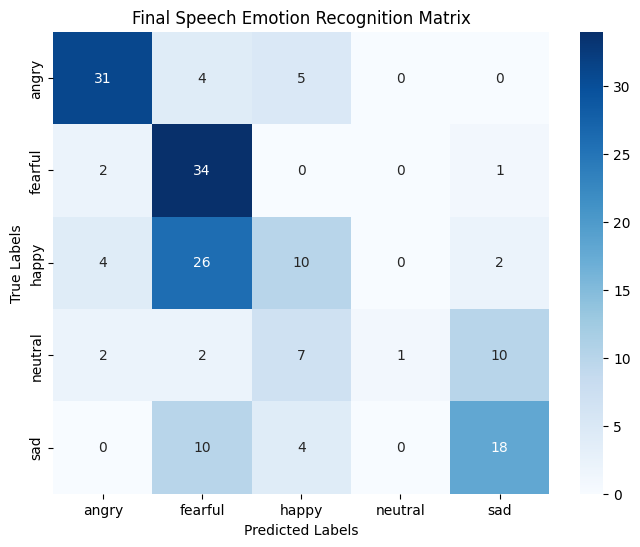

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import  classification_report, confusion_matrix

# Predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# 1. Print Complete Classification Report (Precision, Recall, F1-Score per class)
print("===================  DELIVERABLE: EVALUATION METRICS ===================")
report = classification_report(y_true_classes, y_pred_classes, target_names=le.classes_)
print(report)
print("================================================================================")

# 2. Plotting Confusion Matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Final Speech Emotion Recognition Matrix')
plt.show()

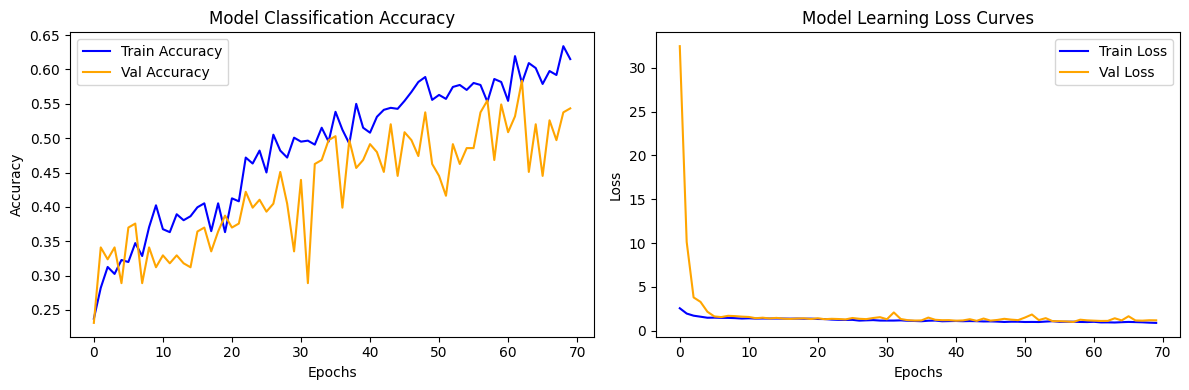

In [ ]:
import matplotlib.pyplot as plt

# Plotting Training vs Validation Accuracy and Loss Curves
plt.figure(figsize=(12, 4))

# 1. Accuracy Chart
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', color='orange')
plt.title('Model Classification Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# 2. Loss Chart
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Val Loss', color='orange')
plt.title('Model Learning Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
import gradio as gr

def predict_emotion_from_ui(audio_file):
    if audio_file is None:
        return "Please record or upload an audio file."

    # Extract features from the recorded file using our previous function
    features = extract_all_features(audio_file)
    features = np.expand_dims(features, axis=0)
    features = np.expand_dims(features, axis=-1)

    # Model prediction
    prediction = model.predict(features)

    # Create dictionary of confidence scores for the UI
    scores = {le.classes_[i]: float(prediction[0][i]) for i in range(len(le.classes_))}
    return scores

# Launching Gradio Web UI App inside Colab
interface = gr.Interface(
    fn=predict_emotion_from_ui,
    inputs=gr.Audio(type="filepath", label="Record your speech"),
    outputs=gr.Label(num_top_classes=3, label="Predicted Emotion"),
    title="Real-Time Speech Emotion Recognition",
    description="Click on the microphone icon, speak with an emotion (Happy, Sad, Angry, Neutral, Fearful), and click Submit!"
)

interface.launch(inline=True, share=True, debug=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://d583faa16a3b763949.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
